# 03. Dynamiques temporelles

Ce notebook trace l’évolution du **positionnement discursif** (score de -2 à +2 attribué à chaque texte) dans le temps. On mobilise une analyse de **shift temporel** (écart avant/après) pour mesurer l’impact des **événements pivot** — moments clés comme les décisions du CIJ, l’offensive de Rafah ou les mandats CPI — sur les trajectoires par bloc. On compare également le discours du Centre sur Twitter et à l’Assemblée nationale, on examine l’attrition différentielle par bloc et les tendances Mann-Kendall. La **variabilité du Centre** désigne le fait que le bloc centriste présente des évolutions plus marquées que les extrêmes, potentiellement en raison d’une position moins ancrée.

## Setup et configuration

Les bibliothèques et les deux versions du corpus, principal et par fenêtres événementielles, sont chargés.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from config import PROJECT_ROOT, RESULTS_DIR, FIGURES_DIR, BLOC_COLORS, BLOC_ORDER, EVENTS, add_events, format_dates

FIG_DIR = Path("../figures")
RES_DIR = Path("../data/results")
FIG_DIR.mkdir(exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib as mpl
mpl.rcParams.update({
    'figure.constrained_layout.use': True,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 11,
})

def save(name):
    plt.savefig(FIG_DIR / f'{name}.png')
    plt.show()

## Chargement du corpus

Le corpus principal et le corpus par fenêtres événementielles sont chargés pour permettre les comparaisons temporelles et l’analyse shift temporel.

In [2]:
from config import CORPUS_V3, CORPUS_V4
df = pd.read_parquet(CORPUS_V3)
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M').astype(str)
df['group'] = df.get('group', df.get('groupe_politique', 'UNKNOWN'))

df_v4 = pd.read_parquet(CORPUS_V4)
df_v4['date'] = pd.to_datetime(df_v4['date'])
df_v4['month'] = df_v4['date'].dt.to_period('M').astype(str)

print(f"Corpus principal : {len(df):,} textes. Corpus par fenêtres événementielles : {len(df_v4):,} textes.")

Corpus principal : 10,774 textes. Corpus par fenêtres événementielles : 5,905 textes.


## Fig 10 : Évolution mensuelle du positionnement par bloc

Le graphique en ruban représente l’évolution du score moyen de positionnement discursif par bloc et par mois. Les courbes illustrent la trajectoire temporelle de chaque famille politique.

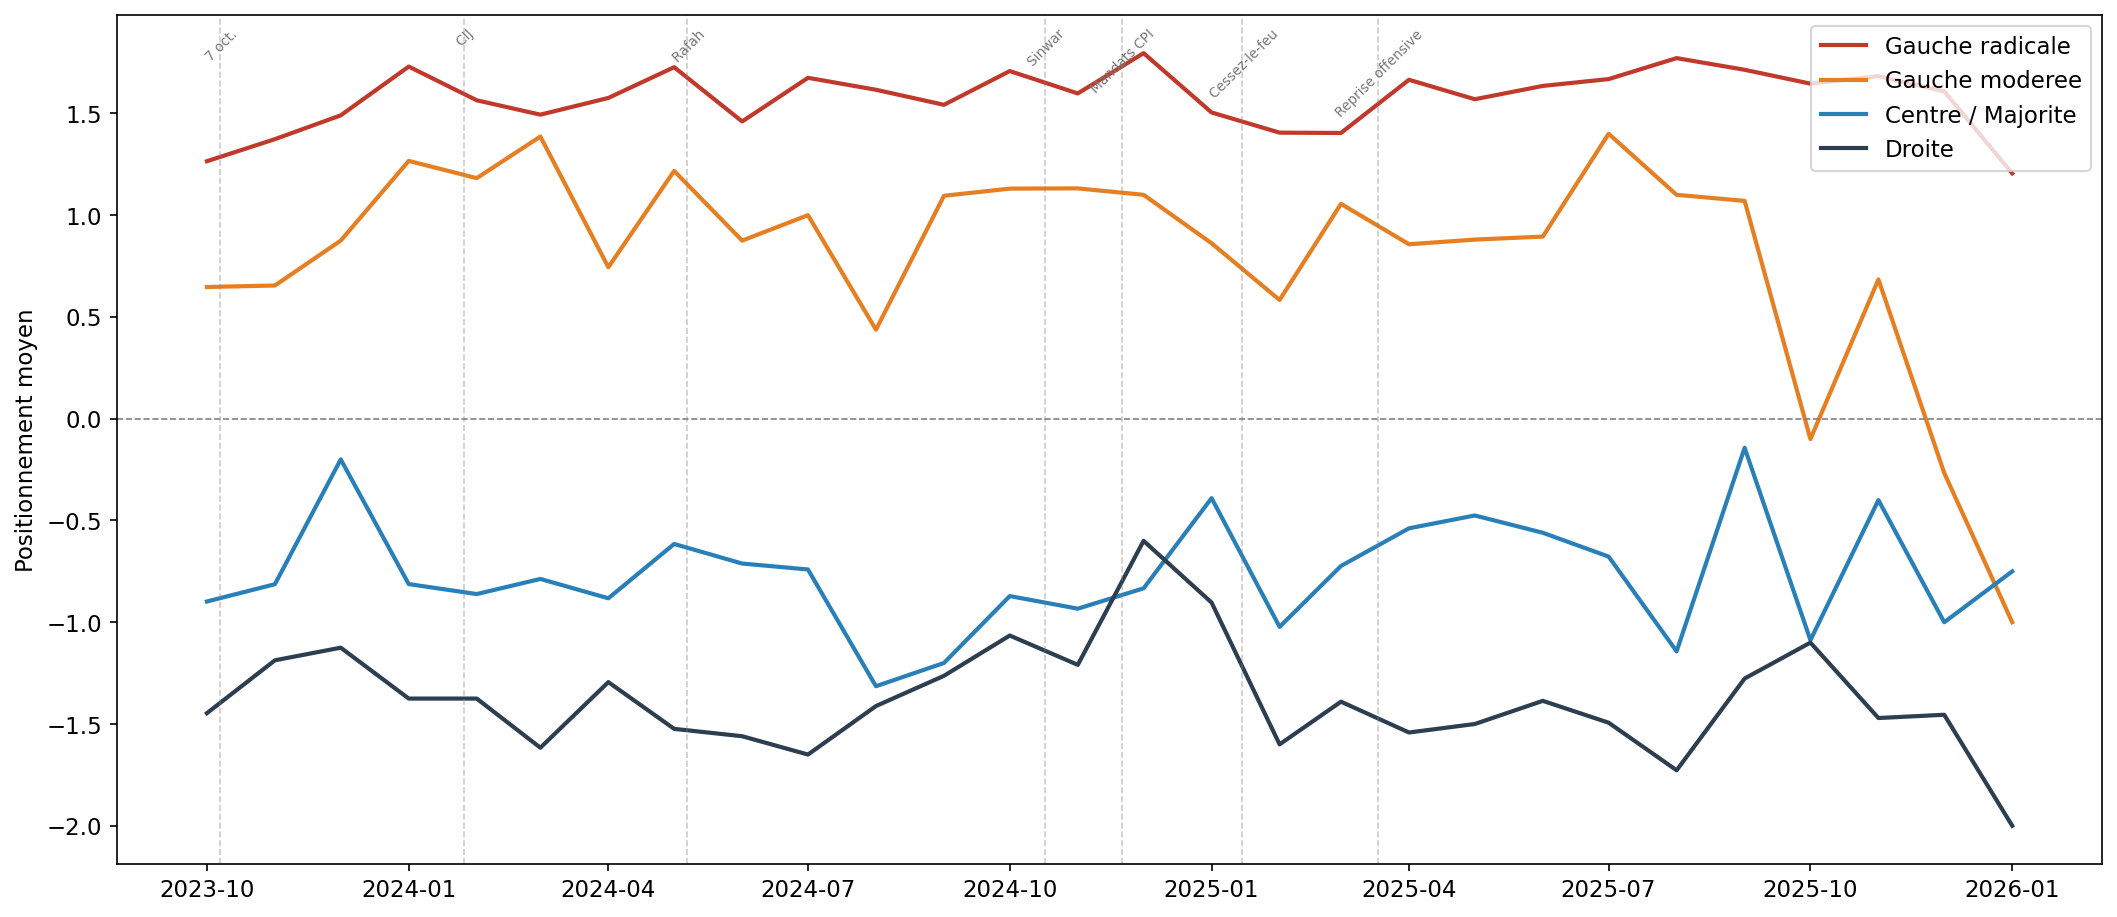

In [3]:
stance_m = df[df['bloc'].isin(BLOC_ORDER)].groupby(['month', 'bloc'])['stance_v3'].mean().reset_index()
stance_m['month_ts'] = pd.to_datetime(stance_m['month'] + '-01')
stance_m.to_csv(RES_DIR / 'stance_mensuel.csv', index=False)

fig, ax = plt.subplots(figsize=(14, 6))
for bloc in BLOC_ORDER:
    sub = stance_m[stance_m['bloc'] == bloc]
    if len(sub) > 0:
        ax.plot(sub['month_ts'], sub['stance_v3'], label=bloc, color=BLOC_COLORS[bloc], lw=2)
add_events(ax)
ax.axhline(0, color='grey', ls='--', lw=0.8)
ax.legend(loc='upper right')
ax.set_ylabel('Positionnement moyen')
save('fig10_stance_ribbon')

Le Centre fluctue nettement au fil du temps tandis que les extrêmes restent stables ; les événements CIJ et Rafah coïncident avec des inflexions visibles du score de positionnement.

## Fig 11-12 : Diff-in-diff (impact événementiel)

La méthode **shift temporel** compare l’évolution du positionnement avant et après un événement pivot entre les blocs traités et un groupe de référence, afin d’estimer l’effet causal de l’événement. On calcule la différence (après – avant) pour chaque bloc et on compare ces variations.

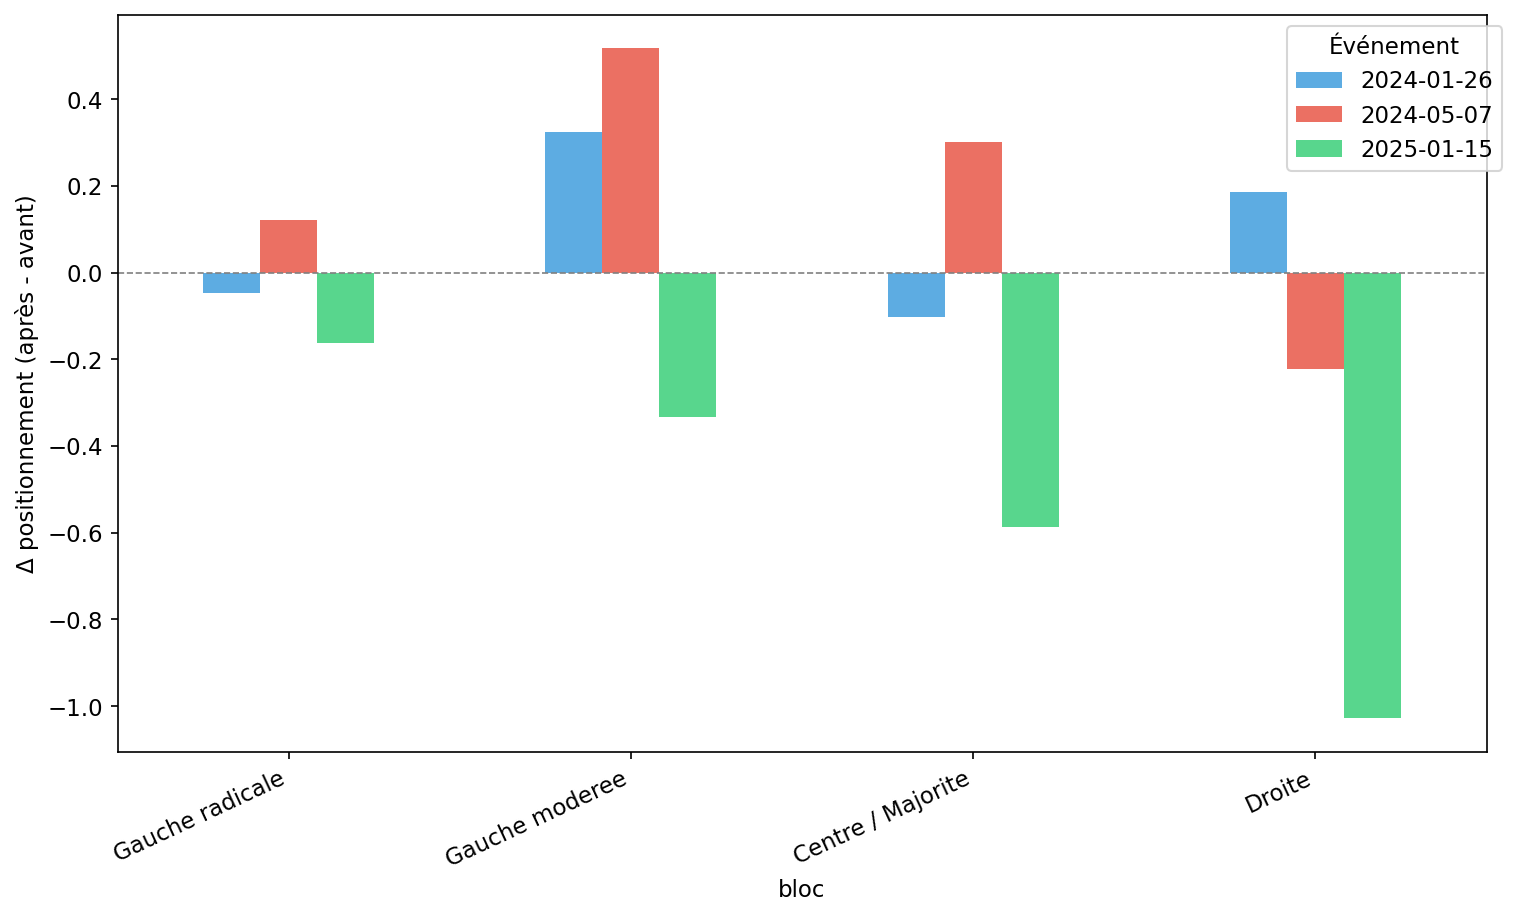

In [4]:
events_did = [('2024-01-26', 30), ('2024-05-07', 30), ('2025-01-15', 30)]
results = []
for ev_date, window in events_did:
    t0 = pd.Timestamp(ev_date)
    before = df[(df['date'] >= t0 - pd.Timedelta(days=window)) & (df['date'] < t0)]
    after = df[(df['date'] >= t0) & (df['date'] < t0 + pd.Timedelta(days=window))]
    for bloc in BLOC_ORDER:
        b_b = before[before['bloc'] == bloc]['stance_v3']
        b_a = after[after['bloc'] == bloc]['stance_v3']
        if len(b_b) >= 5 and len(b_a) >= 5:
            delta = b_a.mean() - b_b.mean()
            from scipy.stats import mannwhitneyu
            _, p = mannwhitneyu(b_a, b_b, alternative='two-sided')
            results.append({'event': ev_date, 'bloc': bloc, 'delta': delta, 'p': p})

did = pd.DataFrame(results)
did.to_csv(RES_DIR / 'event_impact_diff_in_diff.csv', index=False)

if len(did) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    piv = did.pivot(index='bloc', columns='event', values='delta').reindex(BLOC_ORDER)
    piv.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.8)
    ax.axhline(0, color='grey', ls='--', lw=0.8)
    ax.set_ylabel('Δ positionnement (après - avant)')
    ax.legend(title='Événement', bbox_to_anchor=(1.02, 1))
    plt.xticks(rotation=25, ha='right')
    save('fig12_diff_in_diff')

## Distance de Wasserstein (convergence inter-blocs)

La distance de Wasserstein normalisée mesure l'écart entre les distributions de stance. WD faible = convergence ; WD élevée = polarisation. Les CSV sont sauvegardés pour exploitation dans le notebook 04.

In [5]:
from vendeville import wd_inter_blocs, wd_drift_intra_bloc

df_v = df[df['bloc'].isin(BLOC_ORDER)]
pairs = [(b1, b2) for i, b1 in enumerate(BLOC_ORDER) for b2 in BLOC_ORDER[i+1:]]
wd_inter = wd_inter_blocs(df_v, pairs)
wd_drift_list = [wd_drift_intra_bloc(df_v, bloc) for bloc in BLOC_ORDER]
wd_drift = pd.concat([d for d in wd_drift_list if len(d) > 0], ignore_index=True)
wd_inter.to_csv(RES_DIR / 'wasserstein_inter_blocs.csv', index=False)
wd_drift.to_csv(RES_DIR / 'wasserstein_drift.csv', index=False)

print(wd_inter)
print(wd_drift)

       month                                  pair   wd_norm
0    2023-10     Gauche radicale vs Gauche moderee  0.154514
1    2023-10  Gauche radicale vs Centre / Majorite  0.540789
2    2023-10             Gauche radicale vs Droite  0.677946
3    2023-10   Gauche moderee vs Centre / Majorite  0.386275
4    2023-10              Gauche moderee vs Droite  0.523431
..       ...                                   ...       ...
158  2025-12             Gauche radicale vs Droite  0.765698
159  2025-12   Gauche moderee vs Centre / Majorite  0.183333
160  2025-12              Gauche moderee vs Droite  0.296970
161  2025-12           Centre / Majorite vs Droite  0.113636
162  2026-01  Gauche radicale vs Centre / Majorite  0.488870

[163 rows x 3 columns]
       month             bloc   wd_norm
0    2023-10  Gauche radicale  0.000000
1    2023-11  Gauche radicale  0.027094
2    2023-12  Gauche radicale  0.066138
3    2024-01  Gauche radicale  0.116243
4    2024-02  Gauche radicale  0.074832
..  

## Fig 13 : Zoom Centre (stance du bloc Centre uniquement)

Le graphique affiche l'évolution mensuelle du positionnement discursif du seul bloc Centre / Majorité, permettant d'observer sa volatilité face aux événements.

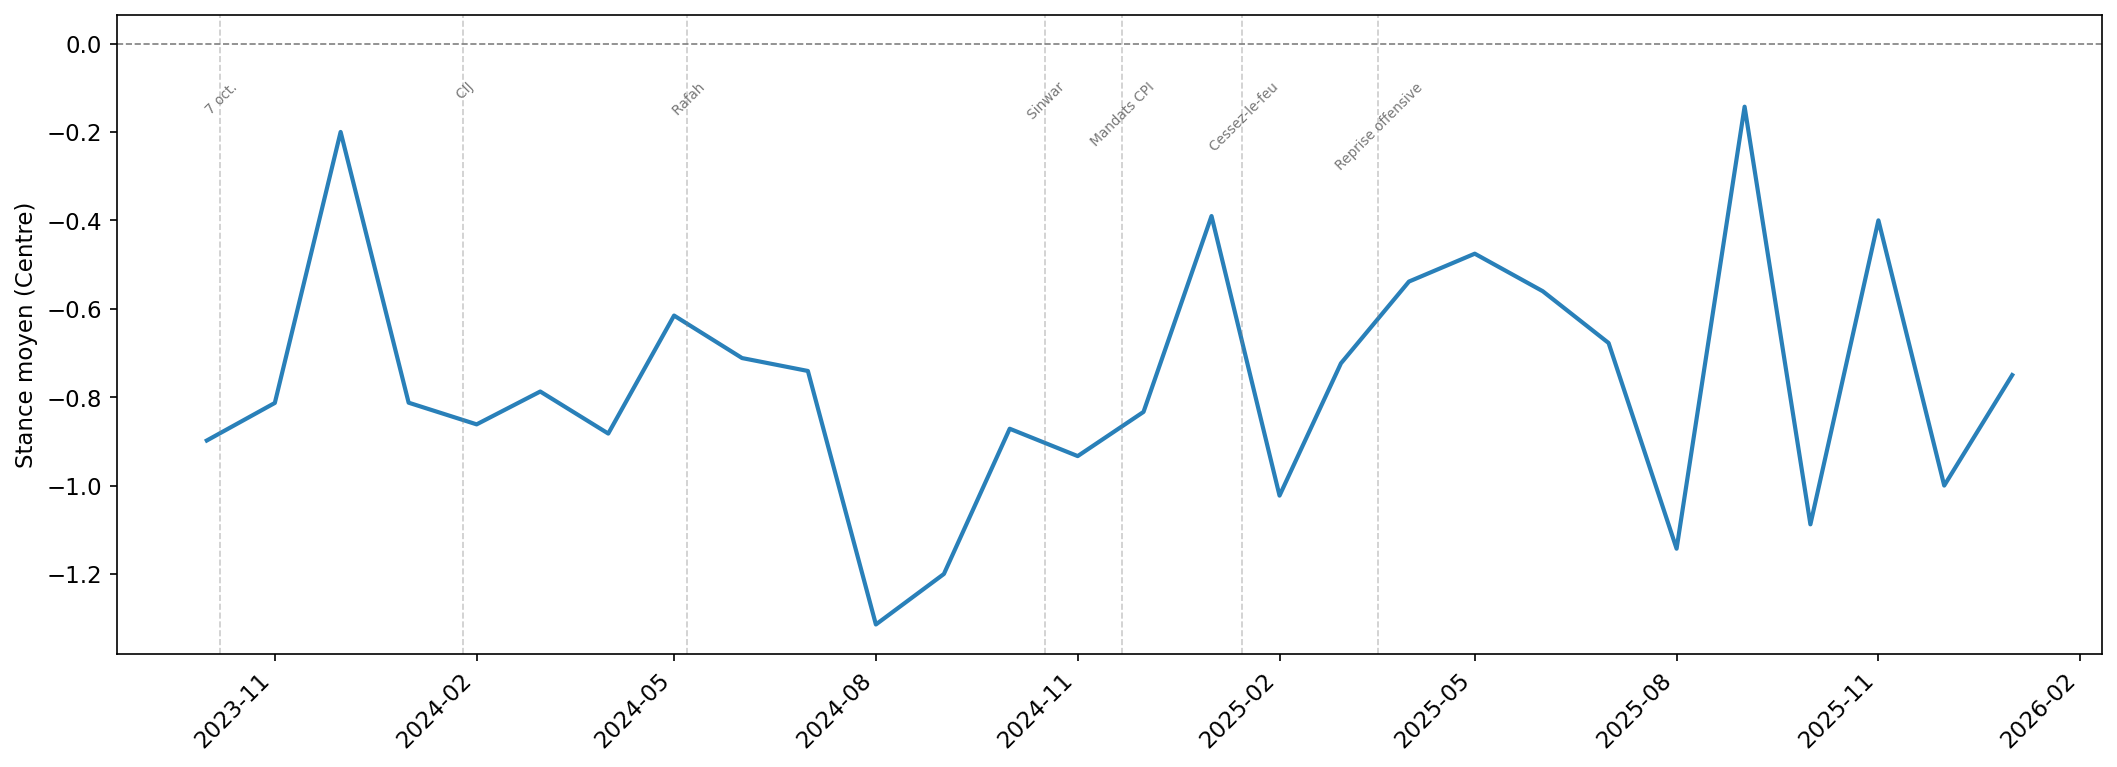

In [6]:
centre_bloc = "Centre / Majorite"
sm = pd.read_csv(RES_DIR / "stance_mensuel.csv")
sm["month_ts"] = pd.to_datetime(sm["month"] + "-01")
centre = sm[sm["bloc"] == centre_bloc]
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(centre["month_ts"], centre["stance_v3"], lw=2, color=BLOC_COLORS.get(centre_bloc, "#2980b9"))
if "stance_se" in centre.columns:
    se = centre["stance_se"]
    ax.fill_between(centre["month_ts"], centre["stance_v3"] - se, centre["stance_v3"] + se, alpha=0.3)
add_events(ax)
format_dates(ax)
ax.set_ylabel("Stance moyen (Centre)")
ax.axhline(0, color="gray", ls="--", lw=0.8)
save("fig13_zoom_centre")

## Fig 14 : Volume et stance (Centre)

Le graphique à deux axes relie le volume de production (nombre de textes) et le stance moyen du bloc Centre sur la période, mettant en évidence les phases d'activité et de positionnement.

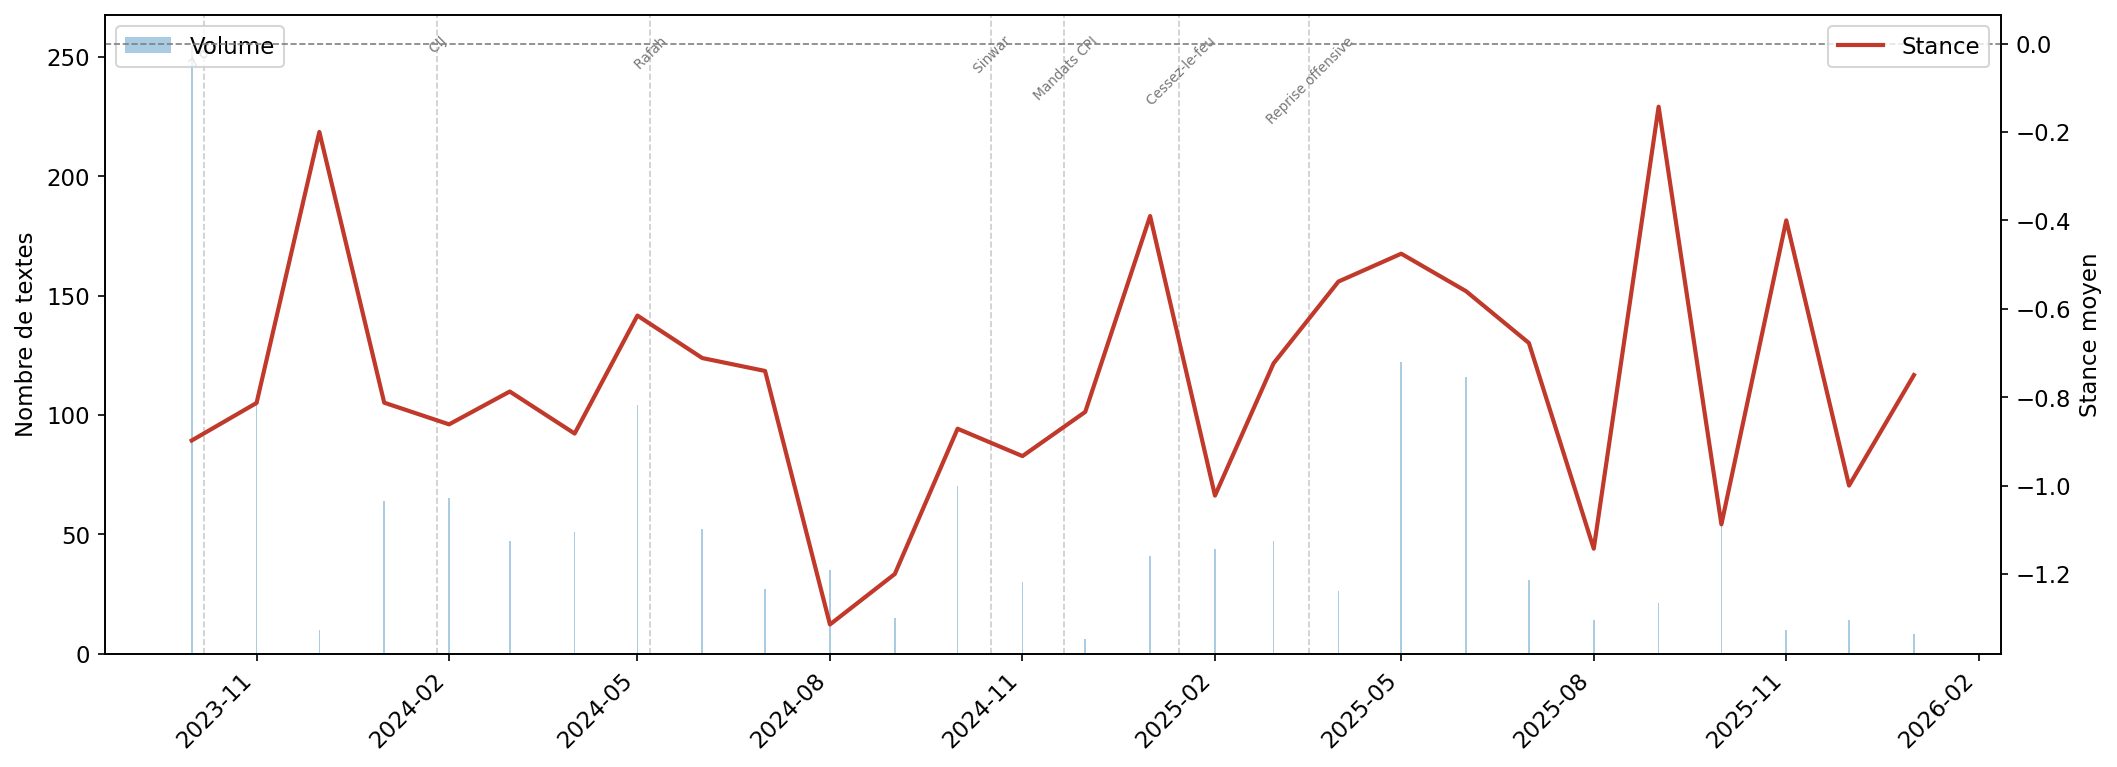

In [7]:
vol = pd.read_csv(RES_DIR / "volume_mensuel.csv")
vol["month_ts"] = pd.to_datetime(vol["month_ts"])
centre_vol = vol[["month_ts", "Centre / Majorite"]].rename(columns={"Centre / Majorite": "n_textes"})
centre_vol = centre_vol.merge(centre[["month_ts", "stance_v3"]], on="month_ts")
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(centre_vol["month_ts"], centre_vol["n_textes"], alpha=0.4, color="#2980b9", label="Volume")
ax1.set_ylabel("Nombre de textes")
ax2 = ax1.twinx()
ax2.plot(centre_vol["month_ts"], centre_vol["stance_v3"], lw=2, color="#c0392b", label="Stance")
ax2.set_ylabel("Stance moyen")
ax2.axhline(0, color="gray", ls="--", lw=0.8)
add_events(ax1)
format_dates(ax1)
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
save("fig14_volume_vs_stance_centre")

Le Centre enregistre les plus grands changements de positionnement après les événements juridiques et militaires, alors que la Gauche radicale et la Droite restent plus fixes — illustration de la variabilité accrue du bloc centriste.

## Fig 13 : Twitter vs Assemblée nationale (Centre)

On compare le positionnement moyen du Centre selon l’arène (Twitter ou Assemblée nationale) pour identifier d’éventuelles différences de cadrage institutionnel versus communication publique.

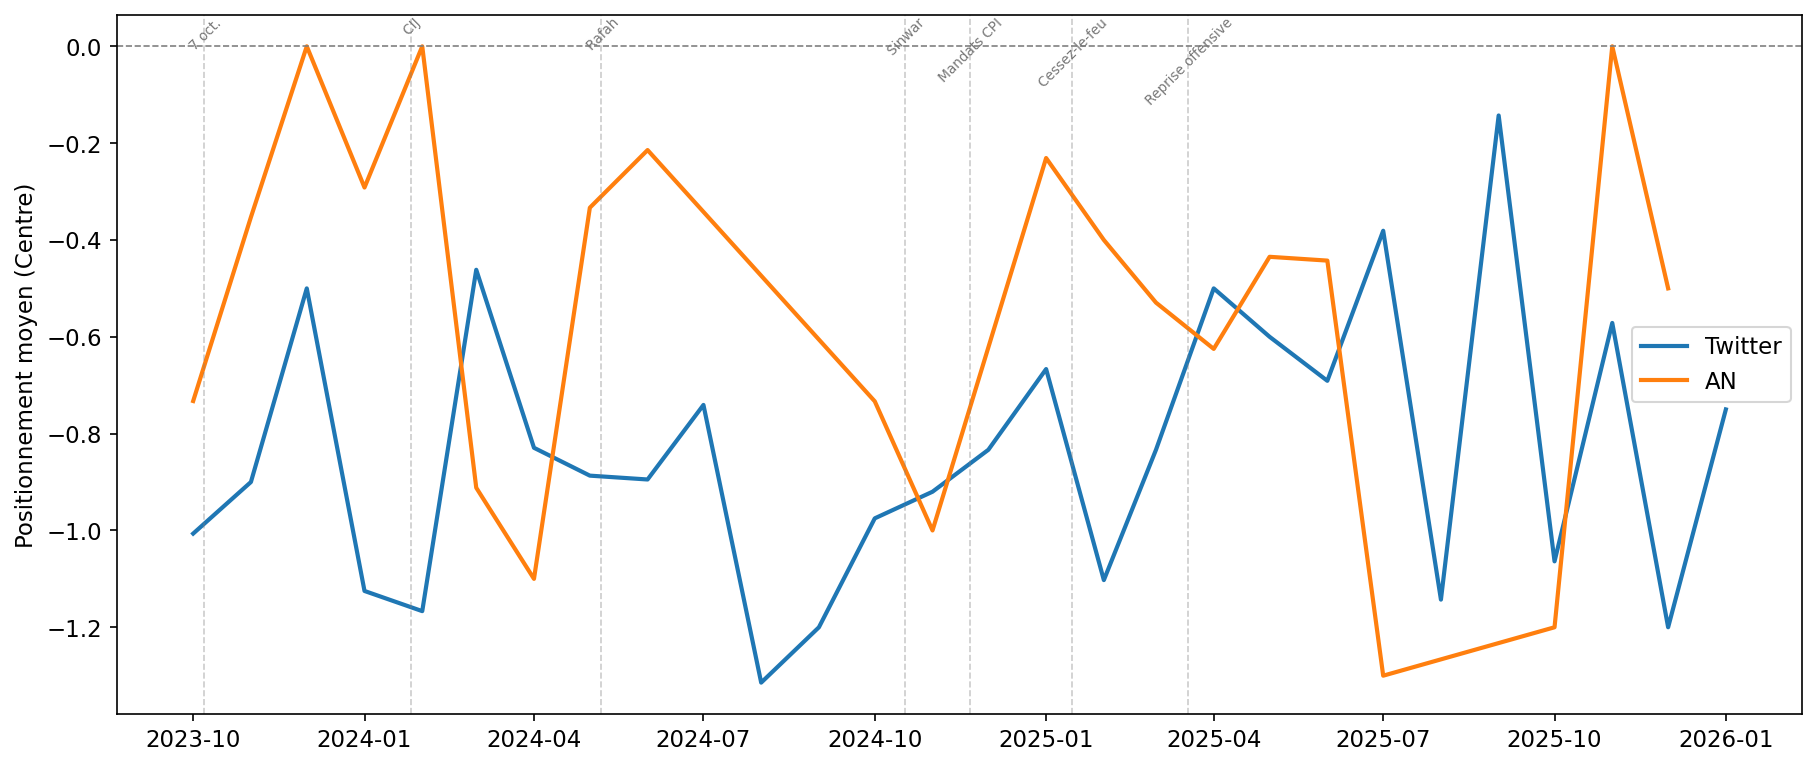

In [8]:
centre = df[(df['bloc'] == 'Centre / Majorite') & (df['arena'].isin(['Twitter', 'AN']))]
centre_m = centre.groupby(['month', 'arena'])['stance_v3'].mean().reset_index()
centre_m['month_ts'] = pd.to_datetime(centre_m['month'] + '-01')

fig, ax = plt.subplots(figsize=(12, 5))
for arena in ['Twitter', 'AN']:
    sub = centre_m[centre_m['arena'] == arena]
    if len(sub) > 0:
        ax.plot(sub['month_ts'], sub['stance_v3'], label=arena, lw=2)
add_events(ax)
ax.axhline(0, color='grey', ls='--', lw=0.8)
ax.legend()
ax.set_ylabel('Positionnement moyen (Centre)')
save('fig15_twitter_vs_an_centre')

Le discours du Centre à l’Assemblée nationale et sur Twitter évolue de façon parallèle ; les écarts ponctuels reflètent le cadre institutionnel versus la communication publique.

## Fig 15b : Stance par arène (tous blocs)

Comparaison Twitter vs Assemblée nationale pour chaque bloc. Un écart systématique signale un cadrage différencié selon l'arène.

## Fig 14 : Attrition différentielle par bloc

L’attrition (baisse du nombre de députés actifs) varie selon les blocs : certains conservent une base de contributeurs plus stable que d’autres.

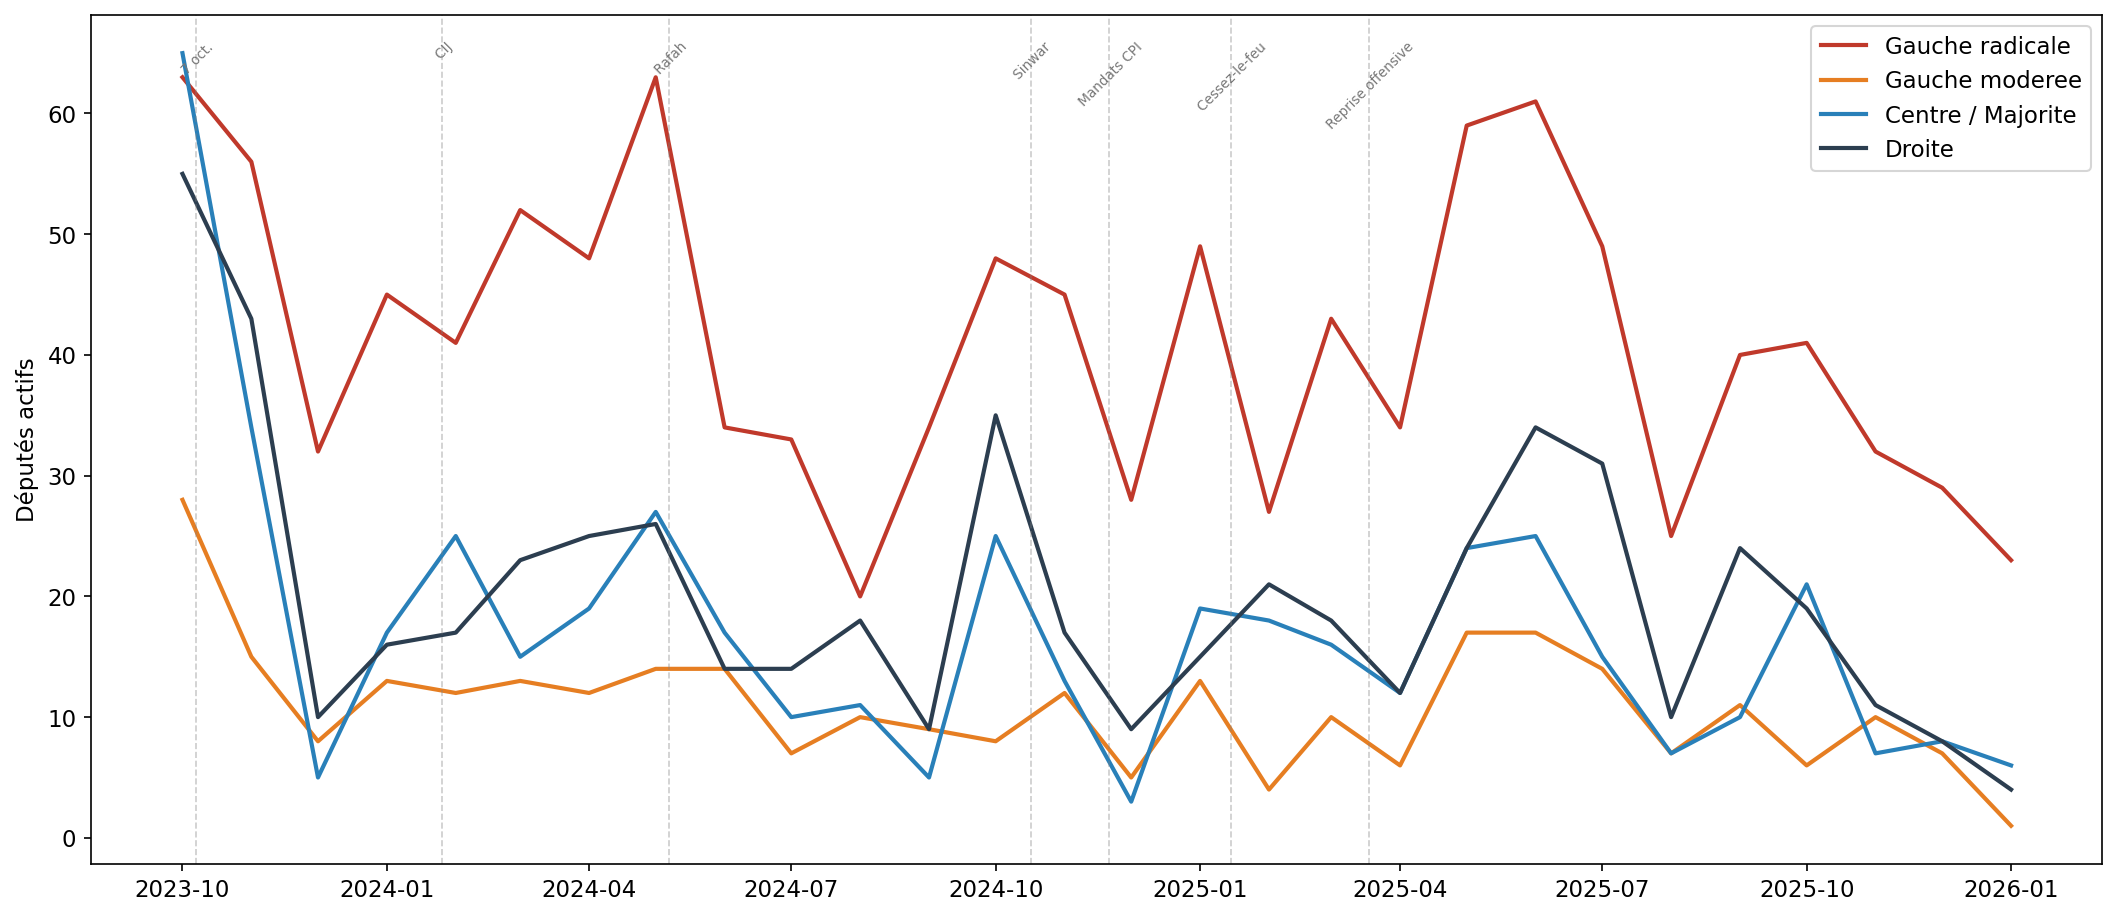

In [9]:
att_bloc = df.groupby(['month', 'bloc']).agg(n_deputes=('author', 'nunique'), n_textes=('author', 'count')).reset_index()
att_bloc['month_ts'] = pd.to_datetime(att_bloc['month'] + '-01')

fig, ax = plt.subplots(figsize=(14, 6))
for bloc in BLOC_ORDER:
    sub = att_bloc[att_bloc['bloc'] == bloc]
    if len(sub) > 0:
        ax.plot(sub['month_ts'], sub['n_deputes'], label=bloc, color=BLOC_COLORS[bloc], lw=2)
add_events(ax)
ax.legend()
ax.set_ylabel('Députés actifs')
save('fig16_attrition_differentielle')

L’attrition est plus marquée à droite et au centre ; la Gauche radicale conserve un volume d’activité élevé jusqu’à la fin de la période.

## Fig 15 : Volume mensuel par bloc (heatmap)

La carte thermique représente la part mensuelle de chaque bloc dans le volume total de production, permettant de visualiser les variations saisonnières et événementielles.

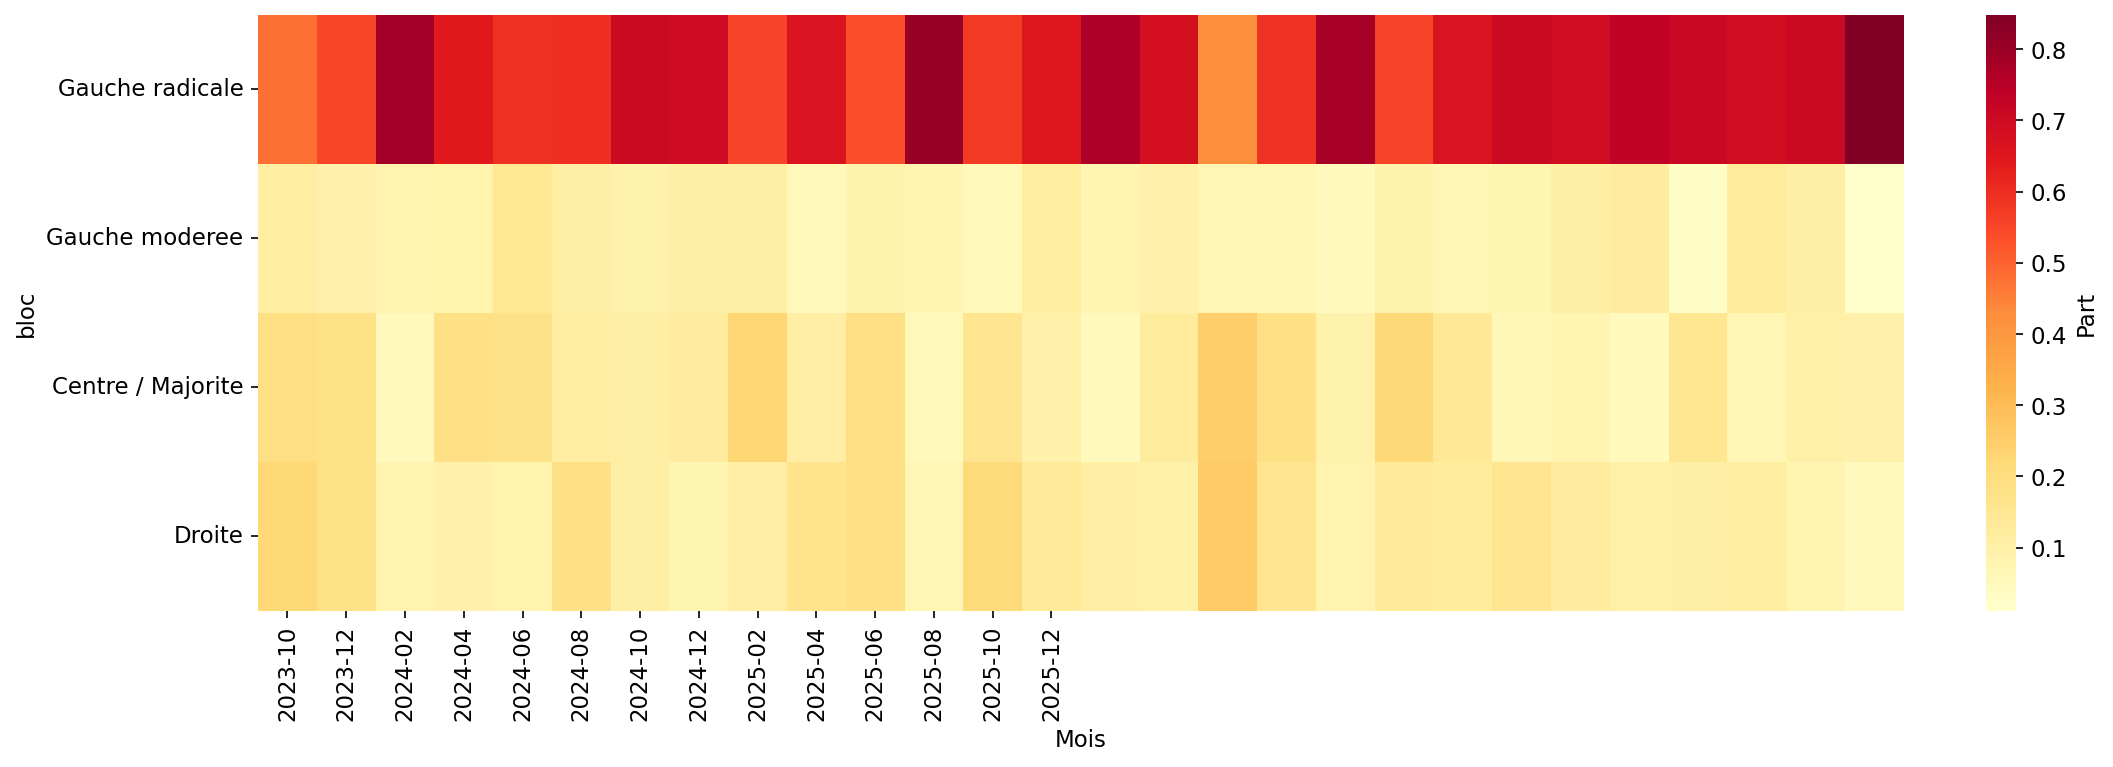

In [10]:
vol = df[df['bloc'].isin(BLOC_ORDER)].groupby(['month', 'bloc']).size().unstack(fill_value=0).reindex(columns=BLOC_ORDER)
vol = vol.fillna(0)
vol_norm = vol.div(vol.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(vol_norm.T, xticklabels=vol.index[::2], yticklabels=BLOC_ORDER, ax=ax, cmap='YlOrRd', cbar_kws={'label': 'Part'})
ax.set_xlabel('Mois')
save('fig17_volume_heatmap')

La part mensuelle de chaque bloc illustre la dominance persistante de la Gauche radicale et les variations saisonnières liées aux événements.

## Fig 16-17 : Test de Mann-Kendall (tendance)

Le test de Mann-Kendall évalue l’existence d’une tendance monotone significative dans la série temporelle du positionnement par bloc. Une valeur non significative indique l’absence de tendance linéaire nette.

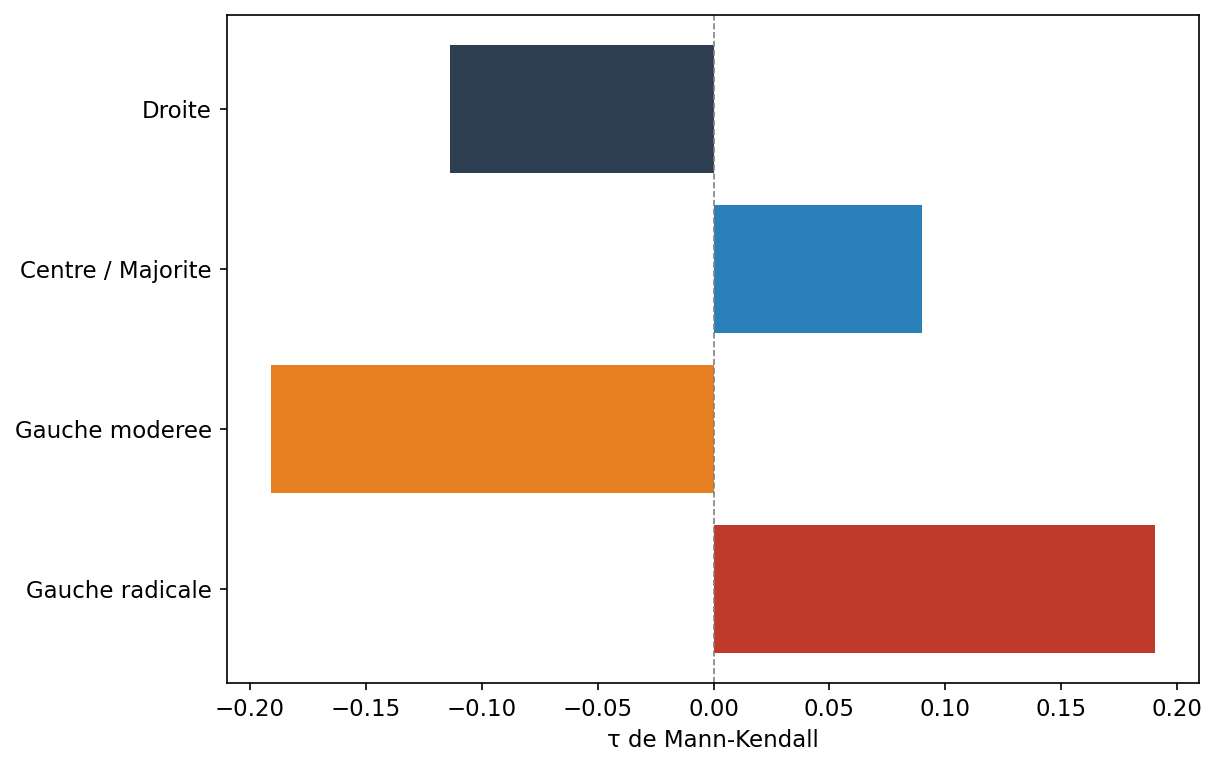

In [11]:
def mann_kendall_tau(series):
    from scipy.stats import kendalltau
    x = np.arange(len(series))
    tau, p = kendalltau(x, series.dropna().values)
    return tau, p

stance_m = df[df['bloc'].isin(BLOC_ORDER)].groupby(['month', 'bloc'])['stance_v3'].mean().reset_index()
mk_results = []
all_months = pd.Series(stance_m['month'].unique()).sort_values()
for bloc in BLOC_ORDER:
    s = stance_m[stance_m['bloc'] == bloc].set_index('month').reindex(all_months).sort_index()['stance_v3']
    tau, p = mann_kendall_tau(s)
    mk_results.append({'bloc': bloc, 'tau': tau, 'p': p})

mk_df = pd.DataFrame(mk_results)
mk_df.to_csv(RES_DIR / 'mann_kendall_bloc.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(mk_df['bloc'], mk_df['tau'], color=[BLOC_COLORS[b] for b in mk_df['bloc']])
ax.axvline(0, color='grey', ls='--', lw=0.8)
ax.set_xlabel('τ de Mann-Kendall')
save('fig18_mann_kendall')

Aucun bloc ne montre une tendance temporelle significative du positionnement ; la stabilité prédomine malgré les variations événementielles ponctuelles.

## Fig 17 : Positionnement mensuel avec intervalles

Le graphique affiche le score moyen de positionnement par bloc et par mois, avec les intervalles d’incertitude (erreur standard) pour tenir compte de la variabilité d’échantillonnage.

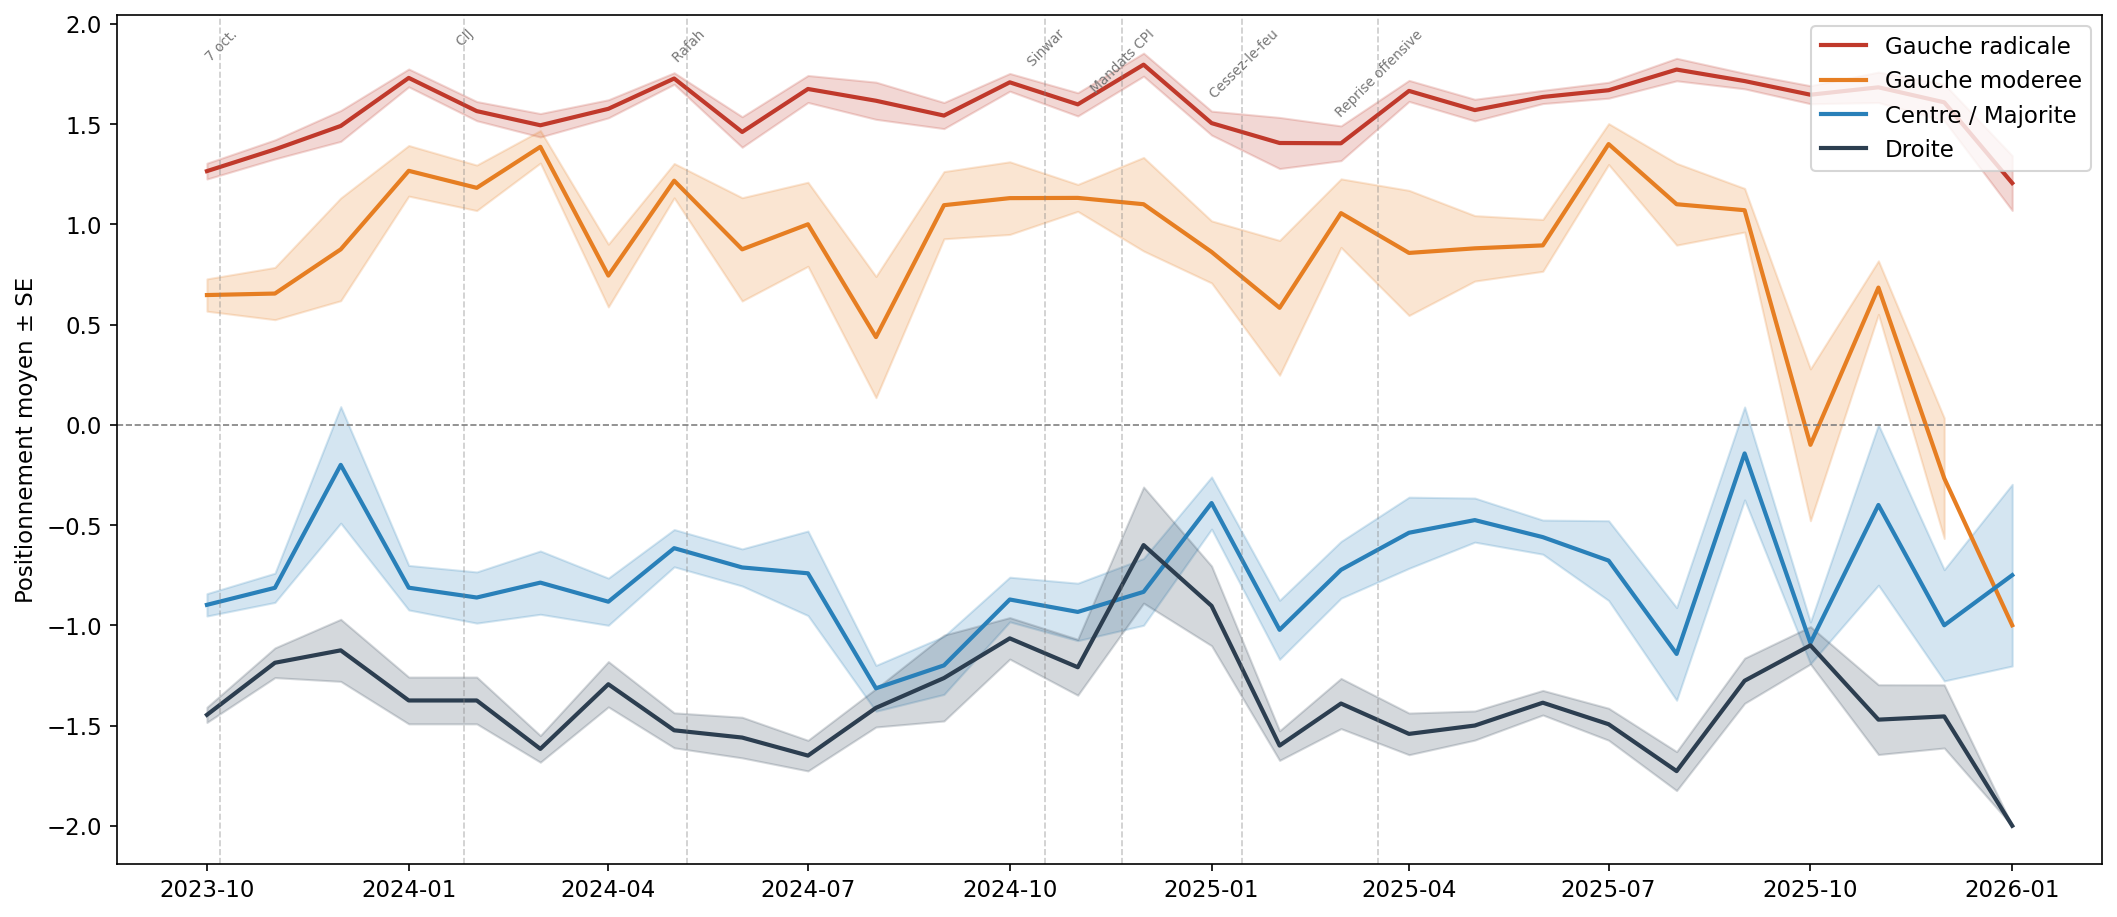

In [12]:
stance_agg = df[df['bloc'].isin(BLOC_ORDER)].groupby(['month', 'bloc'])['stance_v3'].agg(['mean', 'std', 'count']).reset_index()
stance_agg['month_ts'] = pd.to_datetime(stance_agg['month'] + '-01')
stance_agg['se'] = stance_agg['std'] / np.sqrt(stance_agg['count'])

fig, ax = plt.subplots(figsize=(14, 6))
for bloc in BLOC_ORDER:
    sub = stance_agg[stance_agg['bloc'] == bloc]
    if len(sub) > 0:
        ax.plot(sub['month_ts'], sub['mean'], color=BLOC_COLORS[bloc], lw=2, label=bloc)
        ax.fill_between(sub['month_ts'], sub['mean'] - sub['se'], sub['mean'] + sub['se'], color=BLOC_COLORS[bloc], alpha=0.2)
add_events(ax)
ax.axhline(0, color='grey', ls='--', lw=0.8)
ax.legend(loc='upper right')
ax.set_ylabel('Positionnement moyen ± SE')
save('fig11_stance_panel_b4')

L’incertitude autour du positionnement mensuel est plus élevée pour les blocs sous-représentés, notamment la Gauche modérée et le Centre en fin de période.

## Registre discursif : coopération vs conflit

Proportion de discours conflictuel (critiquer, accuser) vs coopératif (informer, proposer) par bloc et mois. Si les positions convergent mais le discours reste conflictuel, la convergence est davantage lexicale que délibérative.

In [ ]:
from registre_discursif import score_registre_discursif

text_col = 'text_clean' if 'text_clean' in df.columns else 'text'
df_valid = df[df['bloc'].isin(BLOC_ORDER)].copy()
df_valid['discourse_score'] = df_valid[text_col].apply(score_registre_discursif)
df_valid['conflictual'] = (df_valid['discourse_score'] > 0.5).astype(int)

delib = df_valid.groupby(['month', 'bloc']).agg(
    pct_conflictual=('conflictual', 'mean'),
    n=('conflictual', 'count')
).reset_index()
delib['month_ts'] = pd.to_datetime(delib['month'] + '-01')
delib = delib[delib['n'] >= 5]
delib.to_csv(RES_DIR / 'deliberative_intensity_by_bloc_month.csv', index=False)

C:\Users\Proprietaire\AppData\Local\Temp\ipykernel_10204\1341970714.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


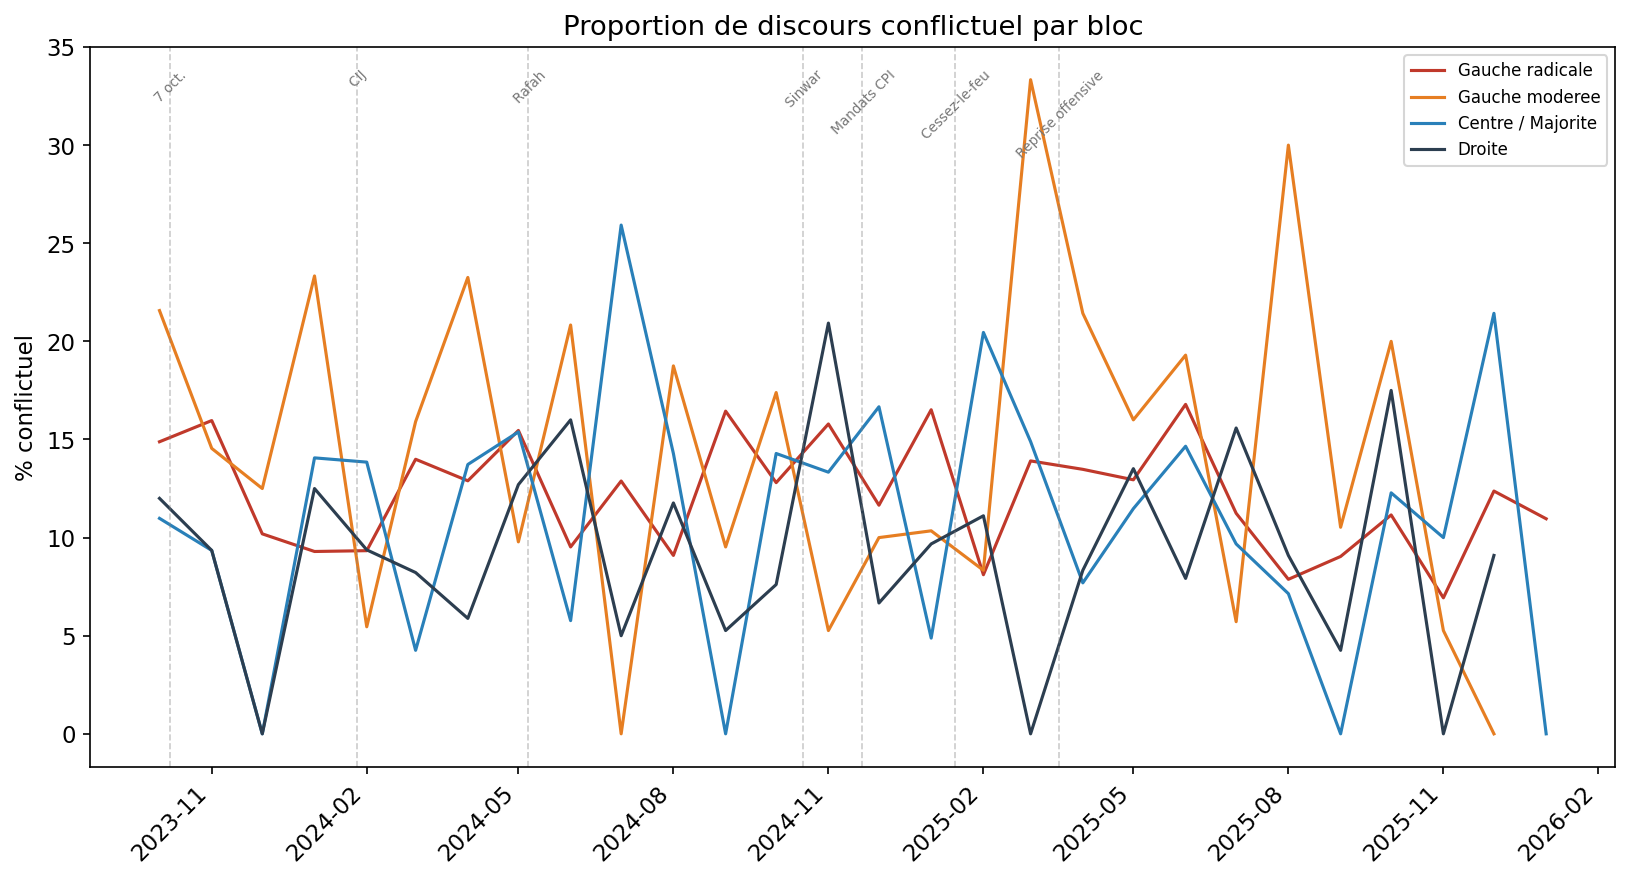

C:\Users\Proprietaire\AppData\Local\Temp\ipykernel_10204\1341970714.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


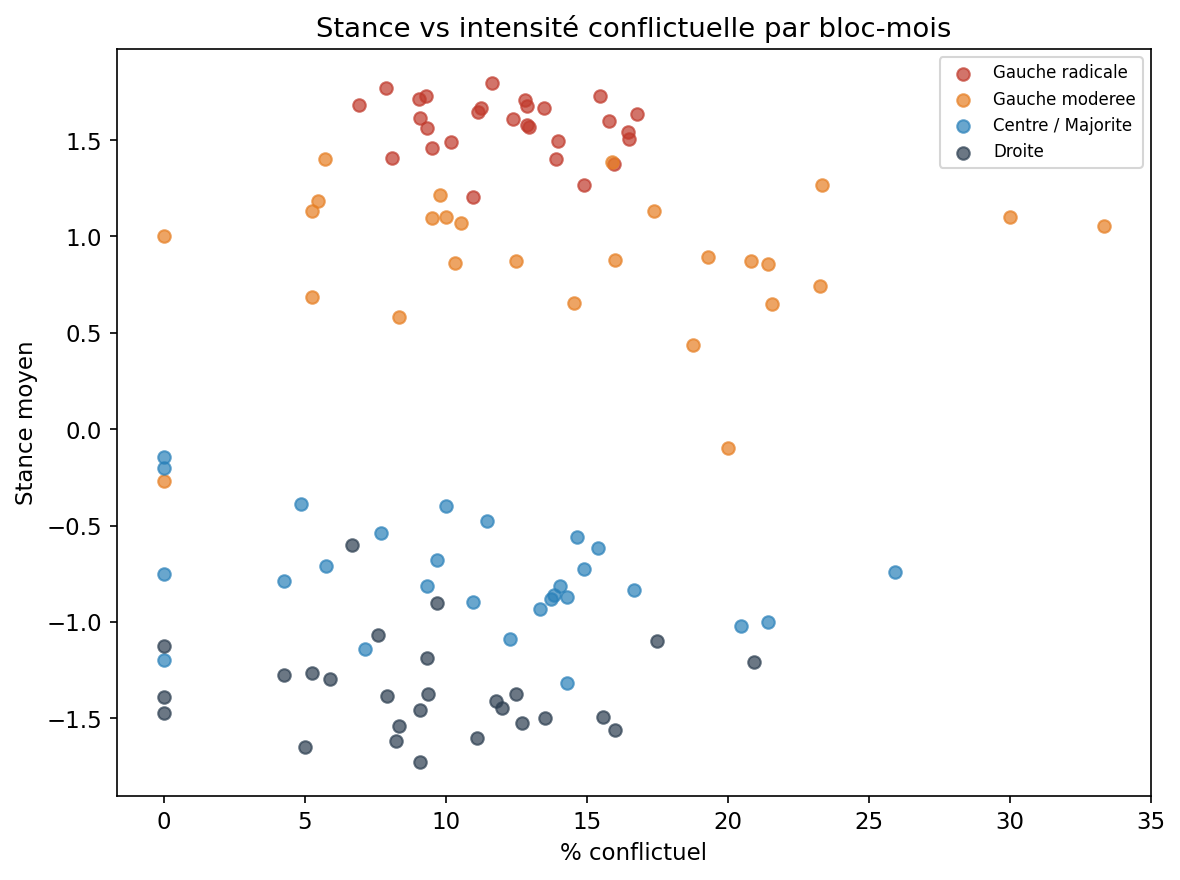

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))
for bloc in BLOC_ORDER:
    sub = delib[delib['bloc'] == bloc]
    if len(sub) > 0:
        ax.plot(sub['month_ts'], sub['pct_conflictual'] * 100, label=bloc, color=BLOC_COLORS.get(bloc, '#888'), lw=1.5)
add_events(ax)
ax.set_ylabel('% conflictuel')
ax.set_title('Proportion de discours conflictuel par bloc')
ax.legend(fontsize=8)
format_dates(ax)
plt.tight_layout()
save('fig62_deliberative_conflictual_temporal')

fig, ax = plt.subplots(figsize=(8, 6))
stance_bloc = df_valid.groupby(['month', 'bloc'])['stance_v3'].mean().reset_index()
merge_scatter = delib.merge(stance_bloc, on=['month', 'bloc'])
for bloc in BLOC_ORDER:
    sub = merge_scatter[merge_scatter['bloc'] == bloc]
    if len(sub) > 0:
        ax.scatter(sub['pct_conflictual'] * 100, sub['stance_v3'], label=bloc, color=BLOC_COLORS.get(bloc, '#888'), alpha=0.7)
ax.set_xlabel('% conflictuel')
ax.set_ylabel('Stance moyen')
ax.set_title('Stance vs intensité conflictuelle par bloc-mois')
ax.legend(fontsize=8)
plt.tight_layout()
save('fig63_stance_vs_conflictual')